# 05 - Advanced Models

## Objective

The purpose of this notebook is to train and evaluate an advanced machine learning model for predicting California home sale prices.

In this notebook, we will:

- Load the cleaned training and testing datasets created during preprocessing.
- Train multiple versions of an XGBoost Regression model.
- Perform light hyperparameter tuning by adjusting the maximum tree depth, learning rate, and number of boosting rounds.
- Evaluate each version using the same performance metrics as the previous models.
- Compare the results to identify which configuration produces the most accurate home price predictions.

The results from this notebook will determine whether gradient boosting improves predictive performance over the previously developed Linear Regression, Decision Tree, and Random Forest models.

In [1]:
# ============================================
# Import required libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# Display all columns when inspecting DataFrames
pd.set_option("display.max_columns", None)

## Load the Cleaned Datasets

The preprocessing notebook produced separate training and testing datasets that are ready for machine learning.

In this section, we will:

- Load the cleaned training dataset.
- Load the cleaned testing dataset.
- Verify that both datasets were imported successfully.
- Confirm their dimensions before training the advanced machine learning models.

In [2]:
# ============================================
# Load the cleaned training and testing datasets
# ============================================

data_path = Path("../data")

train = pd.read_csv(data_path / "train_cleaned.csv")
test = pd.read_csv(data_path / "test_cleaned.csv")

print("Datasets loaded successfully!\n")

print(f"Training rows: {train.shape[0]:,}")
print(f"Training columns: {train.shape[1]}")

print()

print(f"Testing rows: {test.shape[0]:,}")
print(f"Testing columns: {test.shape[1]}")

Datasets loaded successfully!

Training rows: 409,603
Training columns: 924

Testing rows: 15,886
Testing columns: 924


## Inspect the Datasets

Before training the advanced machine learning models, we'll briefly inspect the datasets to verify that they loaded correctly.

We'll display the first few rows of both the training and testing datasets.

In [3]:
# Display the first few rows of the training dataset
train.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,PropertyAge,BathroomBedroomRatio,LivingAreaPerBedroom,LotSizePerLivingArea,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_SAN DIEGO,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,DistrictName_Acalanes Union High,DistrictName_Acton-Agua Dulce Unified,DistrictName_Adelanto Elementary,DistrictName_Alameda Unified,DistrictName_Albany City Unified,DistrictName_Alhambra Unified,DistrictName_Alisal Union,DistrictName_Alpaugh Unified,DistrictName_Alpine County Unified,DistrictName_Alpine Union Elementary,DistrictName_Alta Loma Elementary,DistrictName_Alta Vista Elementary,DistrictName_Alum Rock Union Elementary,DistrictName_Alview-Dairyland Union Elementary,DistrictName_Alvord Unified,DistrictName_Amador County Unified,DistrictName_Anaheim Elementary,DistrictName_Anaheim Union High,DistrictName_Anderson Union High,DistrictName_Anderson Valley Unified,DistrictName_Antelope Elementary,DistrictName_Antelope Valley Union High,DistrictName_Antioch Unified,DistrictName_Apple Valley Unified,DistrictName_Arcadia Unified,DistrictName_Arcata Elementary,DistrictName_Arcohe Union Elementary,DistrictName_Arena Union Elementary,DistrictName_Armona Union Elementary,DistrictName_Aromas - San Juan Unified,DistrictName_Arvin Union,DistrictName_Atascadero Unified,DistrictName_Atwater Elementary,DistrictName_Auburn Union Elementary,DistrictName_Azusa Unified,DistrictName_Bakersfield City,DistrictName_Baldwin Park Unified,DistrictName_Ballard Elementary,DistrictName_Ballico-Cressey Elementary,DistrictName_Bangor Union Elementary,DistrictName_Banning Unified,DistrictName_Banta Unified,DistrictName_Barstow Unified,DistrictName_Bass Lake Joint Union Elementary,DistrictName_Bassett Unified,DistrictName_Bayshore Elementary,DistrictName_Bear Valley Unified,DistrictName_Beardsley Elementary,DistrictName_Beaumont Unified,DistrictName_Bella Vista Elementary,DistrictName_Belleview Elementary,DistrictNam

In [4]:
# Display the first few rows of the testing dataset
test.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,PropertyAge,BathroomBedroomRatio,LivingAreaPerBedroom,LotSizePerLivingArea,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_SAN DIEGO,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,DistrictName_Acalanes Union High,DistrictName_Acton-Agua Dulce Unified,DistrictName_Adelanto Elementary,DistrictName_Alameda Unified,DistrictName_Albany City Unified,DistrictName_Alhambra Unified,DistrictName_Alisal Union,DistrictName_Alpaugh Unified,DistrictName_Alpine County Unified,DistrictName_Alpine Union Elementary,DistrictName_Alta Loma Elementary,DistrictName_Alta Vista Elementary,DistrictName_Alum Rock Union Elementary,DistrictName_Alview-Dairyland Union Elementary,DistrictName_Alvord Unified,DistrictName_Amador County Unified,DistrictName_Anaheim Elementary,DistrictName_Anaheim Union High,DistrictName_Anderson Union High,DistrictName_Anderson Valley Unified,DistrictName_Antelope Elementary,DistrictName_Antelope Valley Union High,DistrictName_Antioch Unified,DistrictName_Apple Valley Unified,DistrictName_Arcadia Unified,DistrictName_Arcata Elementary,DistrictName_Arcohe Union Elementary,DistrictName_Arena Union Elementary,DistrictName_Armona Union Elementary,DistrictName_Aromas - San Juan Unified,DistrictName_Arvin Union,DistrictName_Atascadero Unified,DistrictName_Atwater Elementary,DistrictName_Auburn Union Elementary,DistrictName_Azusa Unified,DistrictName_Bakersfield City,DistrictName_Baldwin Park Unified,DistrictName_Ballard Elementary,DistrictName_Ballico-Cressey Elementary,DistrictName_Bangor Union Elementary,DistrictName_Banning Unified,DistrictName_Banta Unified,DistrictName_Barstow Unified,DistrictName_Bass Lake Joint Union Elementary,DistrictName_Bassett Unified,DistrictName_Bayshore Elementary,DistrictName_Bear Valley Unified,DistrictName_Beardsley Elementary,DistrictName_Beaumont Unified,DistrictName_Bella Vista Elementary,DistrictName_Belleview Elementary,DistrictNam

## Separate the Features and Target

Machine learning models use one variable as the value they are trying to predict, while all remaining variables are used to help make that prediction.

For this project:

- **ClosePrice** is the target variable because it represents the home's final sale price.
- All remaining columns will be used as predictor variables.

In [5]:
# ============================================
# Separate the predictor variables and target
# ============================================

# X contains all of the information we'll use
# to predict a home's sale price.
X_train = train.drop(columns="ClosePrice")
X_test = test.drop(columns="ClosePrice")

# y contains the actual sale prices we're trying to predict.
y_train = train["ClosePrice"]
y_test = test["ClosePrice"]

## Verify the Training Data

Before training the XGBoost models, we'll verify that the predictor variables (`X`) and target variable (`y`) were separated correctly.

In [6]:
print(f"Training features: {X_train.shape}")
print(f"Training target:   {y_train.shape}")

print()

print(f"Testing features:  {X_test.shape}")
print(f"Testing target:    {y_test.shape}")

Training features: (409603, 923)
Training target:   (409603,)

Testing features:  (15886, 923)
Testing target:    (15886,)


## Why XGBoost?

Extreme Gradient Boosting (XGBoost) is an advanced machine learning algorithm that builds a sequence of decision trees, where each new tree focuses on correcting the prediction errors made by the previous trees.

Unlike Random Forest, which builds many independent trees and averages their predictions, XGBoost builds trees one at a time so that each successive tree improves upon the previous model. This boosting approach often produces more accurate predictions while controlling overfitting through regularization and other optimization techniques.

Because of its strong predictive performance and efficiency, XGBoost is widely used in machine learning competitions and real-world regression problems, making it a natural next step for predicting California home sale prices.

In [7]:
# ============================================
# Train XGBoost Version A
# ============================================

# Create the XGBoost model
xgb_a = XGBRegressor(
    random_state=42
)

# Train the model using the training data
xgb_a.fit(X_train, y_train)

print("XGBoost Version A trained successfully!")

XGBoost Version A trained successfully!


## Generate Predictions

Now that the first XGBoost model has been trained, we can use it to predict home sale prices for the testing dataset.

These predicted values will be compared with the actual sale prices to evaluate the model's performance.

In [8]:
# ============================================
# Generate predictions using XGBoost Version A
# ============================================

xgb_a_predictions = xgb_a.predict(X_test)

## Evaluate XGBoost Version A

We'll calculate the same evaluation metrics used throughout this project:

- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
- R-squared (R²)
- Mean Absolute Percentage Error (MAPE)
- Median Absolute Percentage Error (MdAPE)

Using the same evaluation metrics allows the XGBoost model to be compared fairly with the previously developed Linear Regression, Decision Tree, and Random Forest models.

In [9]:
# ============================================
# Calculate evaluation metrics
# ============================================

xgb_a_mae = mean_absolute_error(y_test, xgb_a_predictions)
xgb_a_rmse = root_mean_squared_error(y_test, xgb_a_predictions)
xgb_a_r2 = r2_score(y_test, xgb_a_predictions)
xgb_a_mape = mean_absolute_percentage_error(y_test, xgb_a_predictions)
xgb_a_mdape = np.median(
    np.abs((y_test - xgb_a_predictions) / y_test)
)

In [10]:
# ============================================
# Display model performance
# ============================================

print("XGBoost Version A Performance\n")

print(f"Mean Absolute Error (MAE): ${xgb_a_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${xgb_a_rmse:,.2f}")
print(f"R-squared (R²): {xgb_a_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {xgb_a_mape:.2%}")
print(f"Median Absolute Percentage Error (MdAPE): {xgb_a_mdape:.2%}")

XGBoost Version A Performance

Mean Absolute Error (MAE): $194,395.25
Root Mean Square Error (RMSE): $358,527.68
R-squared (R²): 0.8681
Mean Absolute Percentage Error (MAPE): 15.80%
Median Absolute Percentage Error (MdAPE): 11.43%


## Train XGBoost Version B

The first XGBoost model used the library's default hyperparameters.

For Version B, we'll increase the number of boosting rounds (`n_estimators`) while keeping the remaining settings unchanged.

Increasing the number of trees allows the model to learn additional patterns from the training data and may improve predictive performance without substantially increasing model complexity.

In [11]:
# ============================================
# Train XGBoost Version B
# ============================================

# Create the XGBoost model
xgb_b = XGBRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
xgb_b.fit(X_train, y_train)

print("XGBoost Version B trained successfully!")

XGBoost Version B trained successfully!


## Generate Predictions

We'll now use Version B to predict home sale prices for the testing dataset so that its performance can be compared with Version A.

In [12]:
# ============================================
# Generate predictions using XGBoost Version B
# ============================================

xgb_b_predictions = xgb_b.predict(X_test)

## Evaluate XGBoost Version B

We'll calculate the same evaluation metrics used for Version A so that the effect of increasing the number of boosting rounds can be assessed.

In [13]:
# ============================================
# Calculate evaluation metrics
# ============================================

xgb_b_mae = mean_absolute_error(y_test, xgb_b_predictions)
xgb_b_rmse = root_mean_squared_error(y_test, xgb_b_predictions)
xgb_b_r2 = r2_score(y_test, xgb_b_predictions)
xgb_b_mape = mean_absolute_percentage_error(y_test, xgb_b_predictions)
xgb_b_mdape = np.median(
    np.abs((y_test - xgb_b_predictions) / y_test)
)

In [14]:
# ============================================
# Display model performance
# ============================================

print("XGBoost Version B Performance\n")

print(f"Mean Absolute Error (MAE): ${xgb_b_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${xgb_b_rmse:,.2f}")
print(f"R-squared (R²): {xgb_b_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {xgb_b_mape:.2%}")
print(f"Median Absolute Percentage Error (MdAPE): {xgb_b_mdape:.2%}")

XGBoost Version B Performance

Mean Absolute Error (MAE): $178,961.83
Root Mean Square Error (RMSE): $337,463.73
R-squared (R²): 0.8831
Mean Absolute Percentage Error (MAPE): 14.26%
Median Absolute Percentage Error (MdAPE): 10.12%


## Train XGBoost Version C

Version B improved performance by increasing the number of boosting rounds.

For Version C, we'll keep the same number of boosting rounds while increasing the maximum tree depth. Allowing deeper trees may enable the model to capture more complex relationships among the property features, although it also increases the risk of overfitting.

In [15]:
# ============================================
# Train XGBoost Version C
# ============================================

# Create the XGBoost model
xgb_c = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Train the model
xgb_c.fit(X_train, y_train)

print("XGBoost Version C trained successfully!")

XGBoost Version C trained successfully!


## Generate Predictions

We'll now generate predictions using Version C and compare its performance with the previous XGBoost models.

In [16]:
# ============================================
# Generate predictions using XGBoost Version C
# ============================================

xgb_c_predictions = xgb_c.predict(X_test)

## Evaluate XGBoost Version C

We'll calculate the same evaluation metrics used for the previous models to determine whether increasing the maximum tree depth improves predictive performance.

In [17]:
# ============================================
# Calculate evaluation metrics
# ============================================

xgb_c_mae = mean_absolute_error(y_test, xgb_c_predictions)
xgb_c_rmse = root_mean_squared_error(y_test, xgb_c_predictions)
xgb_c_r2 = r2_score(y_test, xgb_c_predictions)
xgb_c_mape = mean_absolute_percentage_error(y_test, xgb_c_predictions)
xgb_c_mdape = np.median(
    np.abs((y_test - xgb_c_predictions) / y_test)
)

In [18]:
# ============================================
# Display model performance
# ============================================

print("XGBoost Version C Performance\n")

print(f"Mean Absolute Error (MAE): ${xgb_c_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${xgb_c_rmse:,.2f}")
print(f"R-squared (R²): {xgb_c_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {xgb_c_mape:.2%}")
print(f"Median Absolute Percentage Error (MdAPE): {xgb_c_mdape:.2%}")

XGBoost Version C Performance

Mean Absolute Error (MAE): $166,971.44
Root Mean Square Error (RMSE): $323,335.41
R-squared (R²): 0.8927
Mean Absolute Percentage Error (MAPE): 12.99%
Median Absolute Percentage Error (MdAPE): 9.02%


## Compare Model Performance

The table below summarizes the performance of the previously developed machine learning models alongside the three XGBoost configurations.

Comparing all models together makes it easier to evaluate whether gradient boosting provides improved predictive performance over the earlier approaches and to identify the strongest overall model.

In [20]:
# ============================================
# Compare model performance
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost A",
        "XGBoost B",
        "XGBoost C"
    ],
    "MAE": [
        "$277,548.62",
        "$215,816.09",
        "$183,335.52",
        f"${xgb_a_mae:,.2f}",
        f"${xgb_b_mae:,.2f}",
        f"${xgb_c_mae:,.2f}"
    ],
    "RMSE": [
        "$471,469.83",
        "$436,478.38",
        "$356,476.24",
        f"${xgb_a_rmse:,.2f}",
        f"${xgb_b_rmse:,.2f}",
        f"${xgb_c_rmse:,.2f}"
    ],
    "R²": [
        "0.7719",
        "0.8045",
        "0.8696",
        f"{xgb_a_r2:.4f}",
        f"{xgb_b_r2:.4f}",
        f"{xgb_c_r2:.4f}"
    ],
    "MAPE": [
        "25.20%",
        "16.02%",
        "14.13%",
        f"{xgb_a_mape:.2%}",
        f"{xgb_b_mape:.2%}",
        f"{xgb_c_mape:.2%}"
    ],
    "MdAPE": [
        "18.64%",
        "10.23%",
        "9.66%",
        f"{xgb_a_mdape:.2%}",
        f"{xgb_b_mdape:.2%}",
        f"{xgb_c_mdape:.2%}"
    ]
})

comparison

,Model,MAE,RMSE,R²,MAPE,MdAPE
0,Linear Regression,"$277,548.62","$471,469.83",0.7719,25.20%,18.64%
1,Decision Tree,"$215,816.09","$436,478.38",0.8045,16.02%,10.23%
2,Random Forest,"$183,335.52","$356,476.24",0.8696,14.13%,9.66%
3,XGBoost A,"$194,395.25","$358,527.68",0.8681,15.80%,11.43%
4,XGBoost B,"$178,961.83","$337,463.73",0.8831,14.26%,10.12%
5,XGBoost C,"$166,971.44","$323,335.41",0.8927,12.99%,9.02%


## Visualize Model Predictions

A scatter plot of the actual and predicted home sale prices provides a visual assessment of the performance of the best-performing XGBoost model.

Points closer to the dashed reference line represent more accurate predictions, while points farther from the line indicate larger prediction errors.

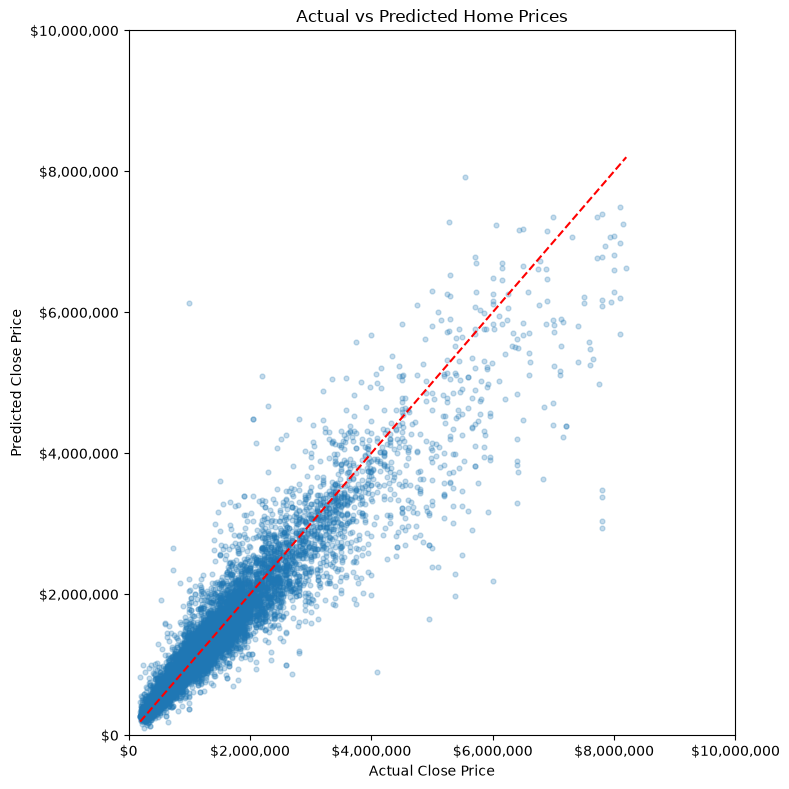

In [22]:
# ============================================
# Compare the model's predicted prices against
# the actual sale prices
# ============================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    xgb_c_predictions,
    alpha=0.25,
    s=12
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Home Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Zoom in to better visualize the vast majority of home sales
limit = 10_000_000

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.tight_layout()
plt.show()

## Interpretation of the Prediction Plot

The scatter plot compares the predicted home sale prices generated by the final XGBoost model with the actual sale prices in the testing dataset.

Points closer to the red dashed reference line indicate more accurate predictions because the predicted sale price closely matches the actual sale price.

Compared with the previous machine learning models, the final XGBoost model produces predictions that follow the diagonal reference line more closely across most home prices. The majority of observations are tightly clustered around the reference line, indicating that predicted sale prices closely match the actual sale prices. Some additional variability remains among the highest-priced homes, where prediction errors become larger, but the overall pattern demonstrates a substantial improvement over the earlier models.

## Advanced Model Results

Three versions of the XGBoost model were trained to evaluate the effect of light hyperparameter tuning.

Version A used the default model settings and produced performance similar to the Random Forest model. Increasing the number of boosting rounds in Version B substantially improved predictive performance across nearly every evaluation metric. Finally, increasing the maximum tree depth in Version C produced the strongest overall results.

The final XGBoost model achieved an **R² of 0.8927**, indicating that it explained approximately **89.3%** of the variation in California home sale prices. It also produced the lowest prediction errors of all models developed during the project, with a **MAPE of 12.99%** and a **MdAPE of 9.02%**.

These results demonstrate that gradient boosting provided the most accurate predictions among the models evaluated in this project.

## Conclusion

This notebook demonstrated that XGBoost further improved predictive performance beyond the previously developed Linear Regression, Decision Tree, and Random Forest models.

By experimenting with multiple model configurations and documenting the effect of each hyperparameter adjustment, the iterative modeling process identified a configuration that consistently reduced prediction error while increasing the proportion of explained variance.

Based on the evaluation metrics, **XGBoost Version C** represents the strongest predictive model developed during the project and serves as the current best-performing model for estimating California home sale prices.